# Modelagem — Telco Customer Churn

## O que esta etapa decide

A [EDA](01_eda_telco.ipynb) terminou com cinco achados e duas decisões pendentes de prova:

1. **`Contract` sozinho já é um classificador razoável** — 42,7% de churn no mês a mês contra 11,3% e 2,8%. Vira o *baseline* que qualquer modelo precisa superar.
2. **`TotalCharges` é reconstituível de `tenure × MonthlyCharges`** (mediana do resíduo 0,00) e ainda mistura dois sinais de direções opostas. Candidata a remoção — mas isso precisa ser medido, não afirmado.

Este notebook compara sete modelos, testa a ablação da segunda decisão e mede uma armadilha específica: o que o balanceamento de classe faz com a *calibração* da probabilidade, que é a matéria-prima da camada de decisão da próxima fase.

**Este notebook não treina nada.** Ele lê os artefatos gravados por `python -m telco_churn.comparacao`, que é o que de fato roda a comparação. A separação é deliberada: um notebook que retreina produz números ligeiramente diferentes a cada execução, e a narrativa passa a divergir da tabela sem ninguém perceber.

> As decisões por trás de cada escolha desta fase — e as alternativas descartadas — estão em [Procedimentos e decisões da fase de modelagem](../docs/procedimentos-e-decisoes-da-fase-de-modelagem.md).


In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 200)

raiz = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
figuras = raiz / "reports" / "figures"

comparacao = json.loads((raiz / "models" / "comparacao.json").read_text(encoding="utf-8"))
producao = json.loads((raiz / "models" / "metricas.json").read_text(encoding="utf-8"))

print(f"campeão: {comparacao['campeao_cv']}")
print(f"líder por PR-AUC: {comparacao['lider_pr_auc']}")
print(f"taxa base no teste: {comparacao['taxa_base_teste']:.4f}")

campeão: XGBoost
líder por PR-AUC: Ensemble (stacking)
taxa base no teste: 0.2654


## 1. O desenho da avaliação

### 1.1. O que não dá para fazer nesta base

A convenção correta em churn seria **split temporal**: treinar em clientes que entraram antes de uma data, testar nos posteriores. É assim que o modelo é usado em produção — prever o futuro a partir do passado.

O Telco não permite isso. **Não há nenhuma coluna de data na base.** `tenure` é duração (quantos meses o cliente tem de casa), não data de entrada; dois clientes com `tenure = 10` podem ter entrado com anos de diferença, e o dado não diz. Sem data de originação, não há safra, e sem safra não há split temporal.

O que resta é split aleatório estratificado por `Churn`. A consequência precisa ser dita: **a performance medida aqui é otimista** em relação ao que se veria em produção, porque treino e teste vêm da mesma janela de tempo e compartilham qualquer efeito de período. Não é um defeito do código — é um limite do dado, e vale mais declará-lo do que escondê-lo.

### 1.2. Por que a escolha não se faz no conjunto de teste

O teste tem 1.409 linhas. Nesse tamanho, o desvio-padrão do ROC-AUC é da ordem de **±0,012** — e as diferenças entre os modelos aprendidos são de ~0,005. Comparar sete modelos por um único split seria escolher o campeão na quarta casa decimal de uma amostra.

Pior: olhar o teste a cada comparação o transforma em conjunto de validação. Depois de sete espiadas, ele deixa de ser uma estimativa honesta de desempenho fora da amostra.

Por isso a escolha se faz por **validação cruzada 5×3 sobre o treino**, e o teste é medido **uma única vez**, no fim.

In [2]:
cv = pd.DataFrame(comparacao["cv_com_total_charges"])
cv[["modelo", "roc_auc_media", "roc_auc_desvio", "pr_auc_media", "pr_auc_desvio",
    "brier_media"]].round(4)

,modelo,roc_auc_media,roc_auc_desvio,pr_auc_media,pr_auc_desvio,brier_media
0,Regra de contrato,0.7289,0.0106,0.4093,0.0095,0.1628
1,Regressão logística,0.8462,0.0117,0.6612,0.0171,0.1351
2,AdaBoost,0.8470,0.0121,0.6601,0.0192,0.1714
3,XGBoost,0.8473,0.0123,0.6677,0.0201,0.1345
4,LightGBM,0.8410,0.0126,0.6569,0.0209,0.1372
5,Ensemble (votação),0.8500,0.0120,0.6710,0.0195,0.1355
6,Ensemble (stacking),0.8505,0.0121,0.6715,0.0183,0.1337


## 2. A escada de modelos

| Modelo | Papel |
|---|---|
| **Regra de contrato** | O baseline de uma linha: `Contract == "Month-to-month"`. |
| **Regressão logística** | Referência interpretável. |
| **AdaBoost, XGBoost, LightGBM** | Três famílias de boosting. |
| **Ensembles (votação e stacking)** | Combinam os quatro modelos que aprendem. |

Uma observação sobre o baseline: ele é implementado como um estimador de verdade, cujo `predict_proba` devolve a **taxa de churn observada no treino dentro de cada grupo** (42,7% para mês a mês, ~7% para o resto). Comparar uma regra que só emite 0 e 1 contra modelos probabilísticos usando Brier ou PR-AUC seria vitória de régua torta — a regra perderia por não estar tentando responder a mesma pergunta.

E a diferença entre votação e stacking: a votação assume que os quatro merecem peso igual; o stacking aprende os pesos com uma logística treinada sobre predições fora da amostra. O segundo é mais poderoso e arrisca sobreajustar no nível de cima — por isso os dois entram na comparação, em vez de eu escolher no palpite.

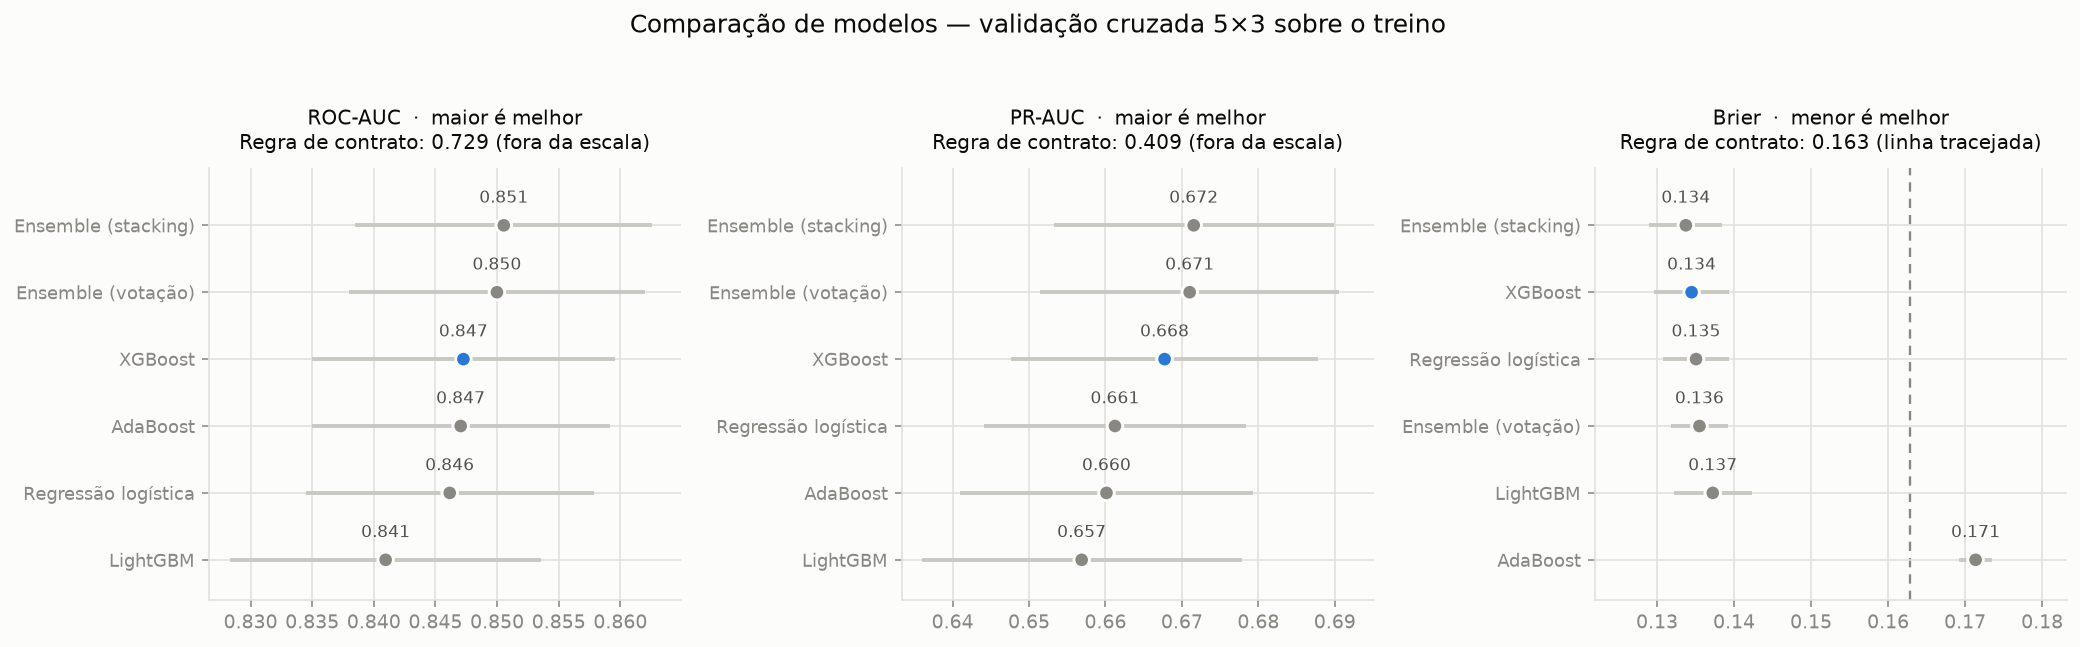

In [3]:
display(Image(filename=str(figuras / "comparacao_metricas.png")))

### 2.1. A primeira leitura: os modelos aprendidos empatam

Repare no que o gráfico mostra e no que ele **não** mostra.

Os seis modelos aprendidos ficam entre 0,841 e 0,851 de ROC-AUC, com barras de erro de ±0,012 que se sobrepõem quase inteiramente. Contra a regra de contrato (0,729, fora da escala do gráfico) a diferença é enorme e inequívoca — **o modelo bate o baseline com folga**. Entre si, a diferença cabe dentro do ruído.

O painel do Brier tem a exceção que vale o gráfico inteiro: **o AdaBoost fica em 0,171 — pior que a regra de uma linha, em 0,163** — apesar de ter ROC-AUC competitivo (0,847). Voltaremos a isso na seção 4.

Se a análise parasse aqui, a conclusão seria "tanto faz, escolha o mais simples". Mas ela pararia cedo demais.

### 2.2. A comparação pareada muda a conclusão

O erro da leitura acima é comparar médias com seus desvios quando os desvios medem a coisa errada.

A variação **entre folds** é grande (±0,019 de PR-AUC): alguns folds são simplesmente mais difíceis que outros. Mas essa dificuldade é **comum a todos os modelos** — um fold difícil é difícil para os sete. Como os folds são compartilhados, a diferença *dentro de cada fold* cancela essa variação comum.

A pergunta certa não é *"a diferença é maior que o desvio entre folds?"* e sim **"o sinal da diferença se mantém fold a fold?"**.

In [4]:
pareado = pd.DataFrame(comparacao["pareado"]).sort_values("pr_auc_media", ascending=False)
pareado[["modelo", "pr_auc_media", "dif_media", "dif_desvio", "folds_vencidos",
         "segundos_por_ajuste"]].round(4)

,modelo,pr_auc_media,dif_media,dif_desvio,folds_vencidos,segundos_por_ajuste
6,Ensemble (stacking),0.6715,0.0103,0.0055,14,8.7714
5,Ensemble (votação),0.6710,0.0098,0.0063,15,1.5283
3,XGBoost,0.6677,0.0065,0.0087,11,0.2337
1,Regressão logística,0.6612,0.0000,0.0000,0,0.0166
2,AdaBoost,0.6601,-0.0011,0.0085,5,0.7015
4,LightGBM,0.6569,-0.0044,0.0102,4,0.6138
0,Regra de contrato,0.4093,-0.2519,0.0170,0,0.0009


E o sinal aparece. Contra a regressão logística, nos mesmos 15 folds:

- **Ensemble (votação): vence em 15 de 15**, com diferença média de +0,0098
- **Ensemble (stacking): vence em 14 de 15**, +0,0103
- **XGBoost: vence em 11 de 15**, +0,0065
- **LightGBM: vence em 4 de 15** e **AdaBoost em 5 de 15** — estes de fato não superam a logística

Um modelo que vence em 15 de 15 folds por pouco é melhor com muito mais confiança do que a comparação de médias sugeria. A diferença é pequena — ~1,5% relativo — mas é real.

### 2.3. A regra de desempate

O líder por PR-AUC é o stacking (0,6715). Mas ele custa **8,84 segundos por ajuste**, contra 0,24s do XGBoost, que empata com ele dentro do ruído da diferença pareada.

A regra adotada, declarada em código: **entre os modelos que empatam com o líder, fica o mais barato de treinar.** Complexidade que não paga em métrica é custo puro — mais tempo de treino, mais superfície de falha no deploy, e um modelo composto de quatro outros é bem mais difícil de defender numa entrevista do que um só.

**Campeão: XGBoost**, 37x mais barato que o líder e estatisticamente indistinguível dele.

In [5]:
teste = pd.DataFrame(comparacao["teste"])
teste[["modelo", "roc_auc", "pr_auc", "brier"]].round(4)

,modelo,roc_auc,pr_auc,brier
0,Regra de contrato,0.7253,0.4063,0.1638
1,Regressão logística,0.8424,0.6359,0.1379
2,AdaBoost,0.8398,0.6486,0.1726
3,XGBoost,0.8448,0.6639,0.1356
4,LightGBM,0.8406,0.6557,0.1368
5,Ensemble (votação),0.8469,0.6623,0.1370
6,Ensemble (stacking),0.8463,0.6576,0.1359


### 2.4. As curvas, no conjunto de teste

Os dois gráficos abaixo usam **ênfase**: o campeão em azul, o baseline em cinza escuro, os demais modelos como faixa cinza clara. Sete curvas coloridas quase sobrepostas pediriam que o leitor distinguisse o que já sabemos ser indistinguível.

Com 26,5% de positivos, a curva que importa é a de **precisão-recall**, não a ROC. O ROC-AUC inclui a facilidade de acertar os negativos, que são a maioria, e por isso parece sempre mais generoso.

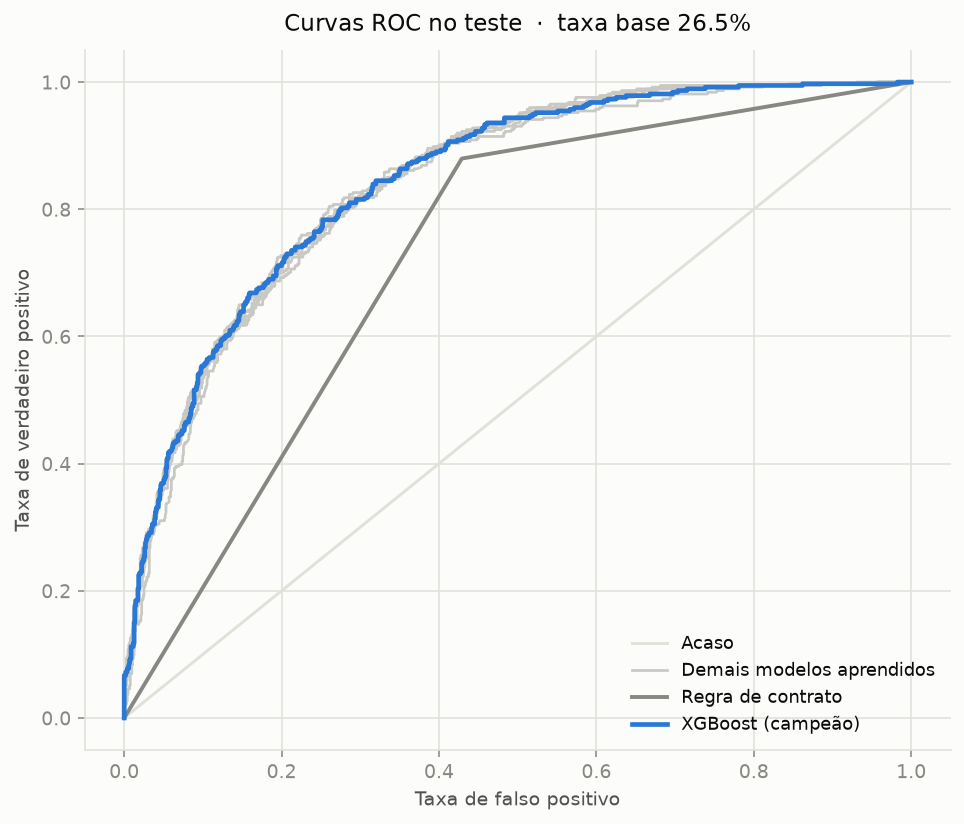

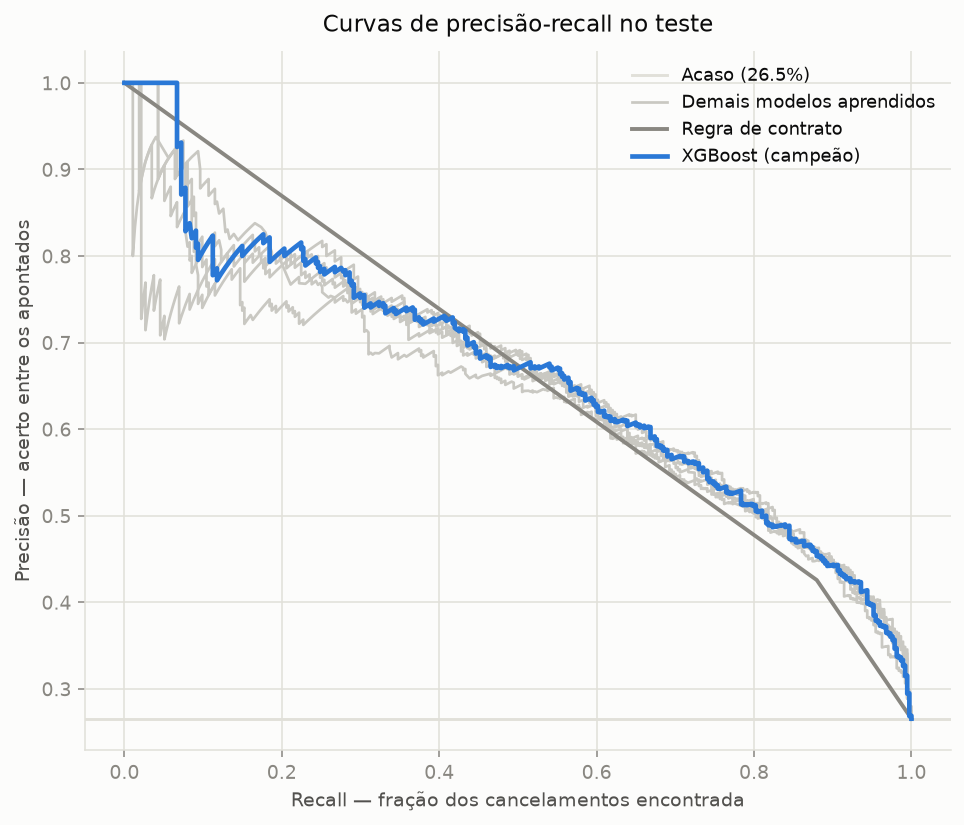

In [6]:
display(Image(filename=str(figuras / "curvas_roc.png")))
display(Image(filename=str(figuras / "curvas_precisao_recall.png")))

Uma ressalva de leitura sobre a curva do baseline: ela aparece como uma reta. Não é suavização — a regra só produz **dois** valores de probabilidade distintos (um por grupo de contrato), então existem apenas dois pontos de corte reais e o que se vê entre eles é interpolação linear. É a assinatura visual de um classificador que não consegue ordenar dentro dos próprios grupos.

## 3. A ablação de `TotalCharges`

A EDA provou que `TotalCharges` é reconstituível a partir de `tenure × MonthlyCharges` — mediana do resíduo exatamente 0,00, IQR de ±28,5 (menos de meio mês de cobrança). E argumentou que ela é **pior que redundante**, porque mistura dois sinais de direções opostas: tenure baixo aumenta o risco, mensalidade alta também, e o produto dos dois embaralha os efeitos.

Argumento é argumento. A pergunta empírica é: **quanto custa remover?**

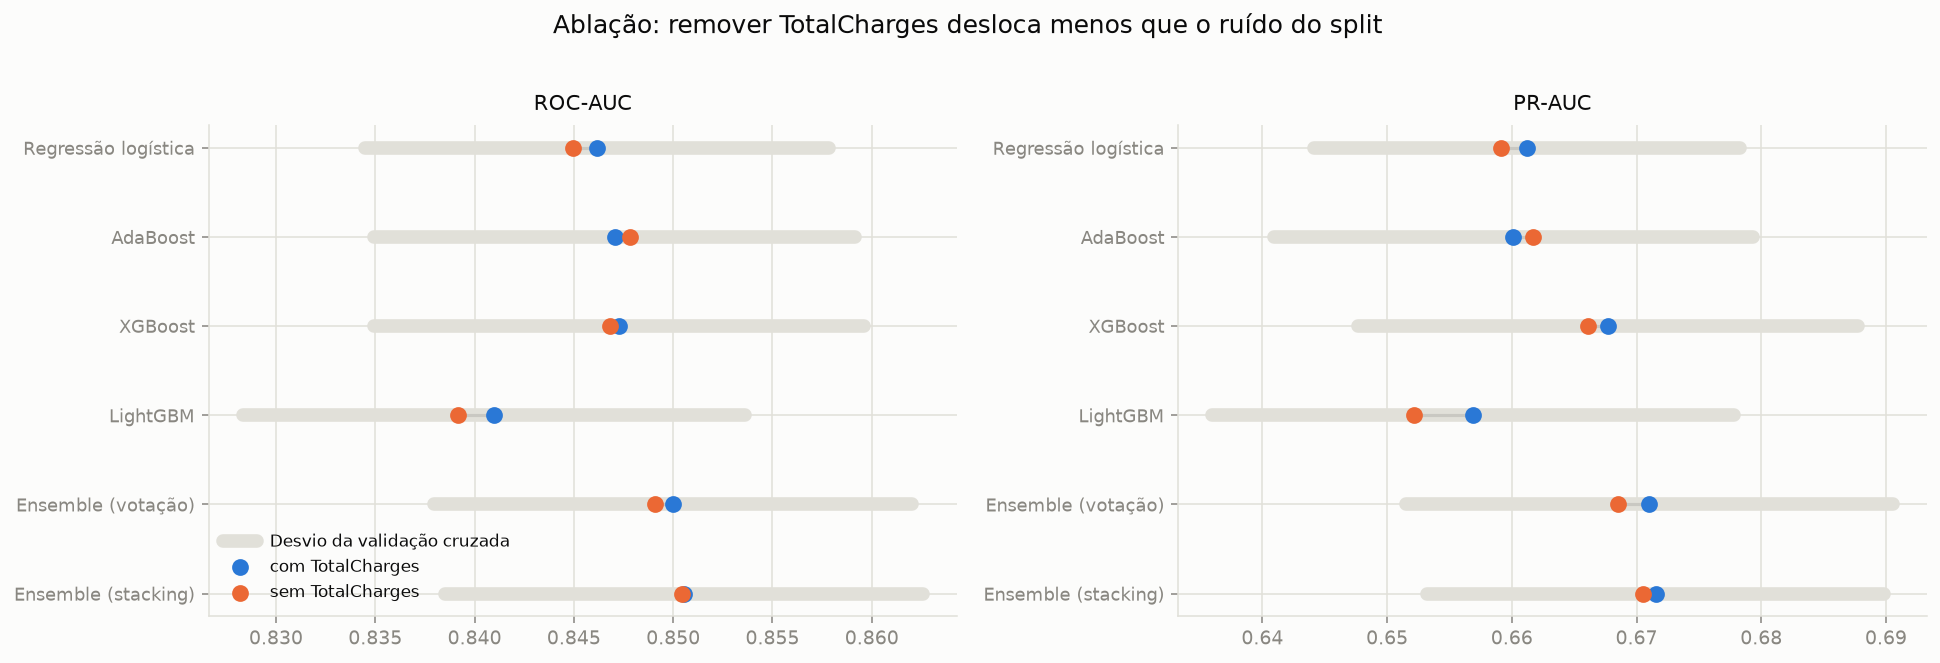

In [7]:
display(Image(filename=str(figuras / "ablacao_total_charges.png")))

In [8]:
com = pd.DataFrame(comparacao["cv_com_total_charges"]).set_index("modelo")
sem = pd.DataFrame(comparacao["cv_sem_total_charges"]).set_index("modelo")

ablacao = pd.DataFrame({
    "roc_com": com["roc_auc_media"],
    "roc_sem": sem["roc_auc_media"],
    "diferenca": sem["roc_auc_media"] - com["roc_auc_media"],
    "desvio_do_fold": com["roc_auc_desvio"],
})
ablacao["diferenca_em_desvios"] = ablacao["diferenca"] / ablacao["desvio_do_fold"]
ablacao.round(4)

,roc_com,roc_sem,diferenca,desvio_do_fold,diferenca_em_desvios
modelo,,,,,
Regra de contrato,0.7289,0.7289,0.0000,0.0106,0.0000
Regressão logística,0.8462,0.8450,-0.0012,0.0117,-0.1008
AdaBoost,0.8470,0.8478,0.0008,0.0121,0.0643
XGBoost,0.8473,0.8468,-0.0004,0.0123,-0.0360
LightGBM,0.8410,0.8392,-0.0018,0.0126,-0.1430
Ensemble (votação),0.8500,0.8491,-0.0009,0.0120,-0.0763
Ensemble (stacking),0.8505,0.8504,-0.0001,0.0121,-0.0094


**Custa nada.** A maior diferença em qualquer modelo é de 0,0018 de ROC-AUC, contra um desvio entre folds de ~0,012 — a coluna `diferenca_em_desvios` mostra que todos os deslocamentos ficam abaixo de 0,15 desvio. No gráfico é ainda mais direto: os dois pontos de cada haltere praticamente se encostam, e o par inteiro cabe dentro da barra cinza que representa o ruído.

Isso converte uma observação da EDA em **decisão de feature defendida**: `TotalCharges` sai do modelo sem custo mensurável de performance, e o modelo fica com uma variável a menos para explicar, monitorar e quebrar em produção.

*(O modelo de produção mantém a variável por ora — a ablação prova que ela pode sair, e a remoção definitiva é uma mudança para tomar junto com a Fase 4, quando as features também alimentarem o simulador do dashboard.)*

## 4. A armadilha da calibração

Aqui está a parte que a maioria dos notebooks de churn pula, e que a próxima fase torna obrigatória.

Com 26,5% de positivos, o reflexo comum é `class_weight="balanced"`. Ele funciona para o que promete: aumenta o recall da classe minoritária. O problema é o que ele faz de lado.

**Ordenar bem e acertar o nível são coisas diferentes.** O ROC-AUC só enxerga a *ordem* das probabilidades — se o modelo multiplicar todas por dois, o ROC-AUC não muda em nada. Mas a Fase 4 vai calcular valor esperado assim:

```
VE(cliente) = p_churn × taxa_aceite × margem × horizonte − custo_da_oferta
```

Esse cálculo usa o **valor absoluto** de `p_churn`. Uma probabilidade inflada dimensiona a campanha inteira errado, por mais perfeito que o ranking esteja.

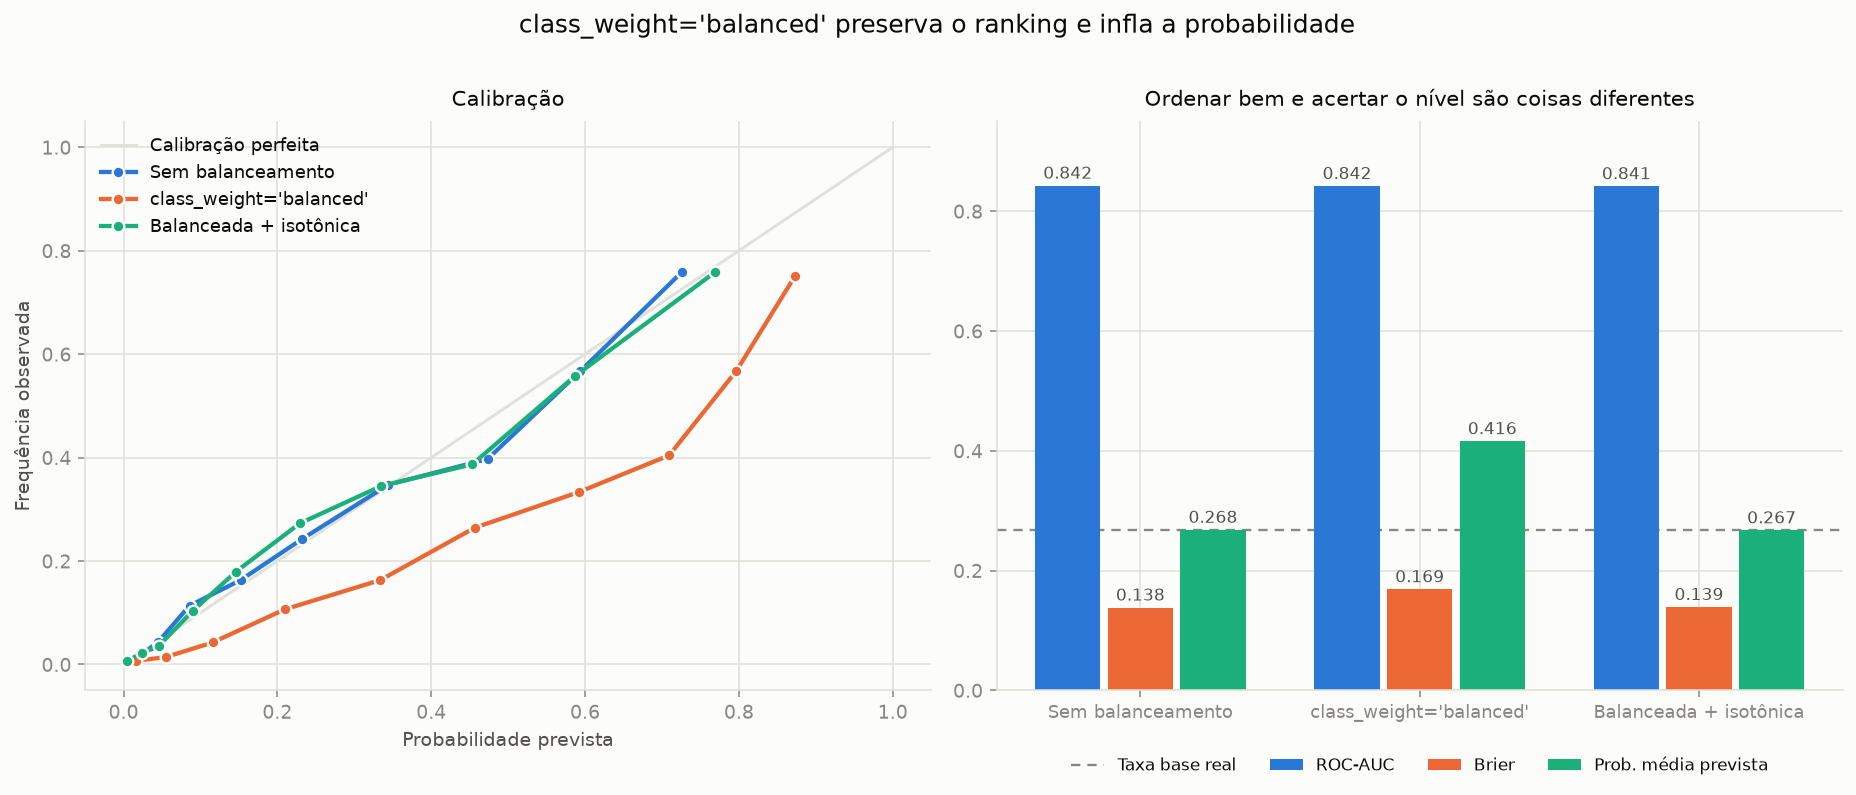

In [9]:
display(Image(filename=str(figuras / "efeito_class_weight.png")))

In [10]:
pd.DataFrame(comparacao["calibracao"]).round(4)

,variante,roc_auc,pr_auc,brier,prob_media
0,Sem balanceamento,0.8424,0.6359,0.1379,0.2678
1,class_weight='balanced',0.8418,0.6341,0.1686,0.4158
2,Balanceada + isotônica,0.8415,0.6316,0.1388,0.2669


A hipótese se confirma com precisão desconfortável:

| Variante | ROC-AUC | Brier | Probabilidade média prevista |
|---|---|---|---|
| Sem balanceamento | 0,8424 | **0,1379** | **0,268** |
| `class_weight="balanced"` | 0,8418 | **0,1686** | **0,416** |
| Balanceada + isotônica | 0,8415 | **0,1388** | **0,267** |

A taxa base real é **0,265**. O modelo sem balanceamento prevê 0,268 em média — calibrado. O balanceado prevê **0,416**: acha que 42% da carteira vai cancelar, quando 26,5% cancela. **Superestima o risco em mais de 50%.**

E o ROC-AUC não denuncia nada disso: 0,8424 contra 0,8418, diferença na terceira casa. Um projeto que reportasse só AUC entregaria à Fase 4 um modelo que infla o valor esperado de toda campanha, e o erro só apareceria quando o retorno real viesse abaixo do previsto.

A recalibração isotônica devolve o Brier a 0,1388 e a média a 0,267, sem custo relevante de ordenação.

**Decisão:** o modelo de produção vai **sem** `class_weight`. A calibração já está boa de origem, e a alternativa é adicionar um estágio de recalibração para consertar um problema que não precisava ser criado.

Uma observação sobre o AdaBoost, que a seção 2.1 deixou pendente: seu Brier de 0,171 é pior que o da regra de uma linha. A curva de calibração mostra por quê — ele fica bem abaixo da diagonal em toda a faixa média, **superestimando o risco** de forma sistemática. É uma característica conhecida da família: o `predict_proba` do AdaBoost deriva da perda exponencial e comprime as probabilidades em torno de 0,5. Ele **ordena** bem (ROC-AUC 0,847) e **mente sobre o nível**. Para a Fase 4, seria o pior candidato da escada — apesar de parecer o quarto melhor numa tabela que só mostrasse AUC.

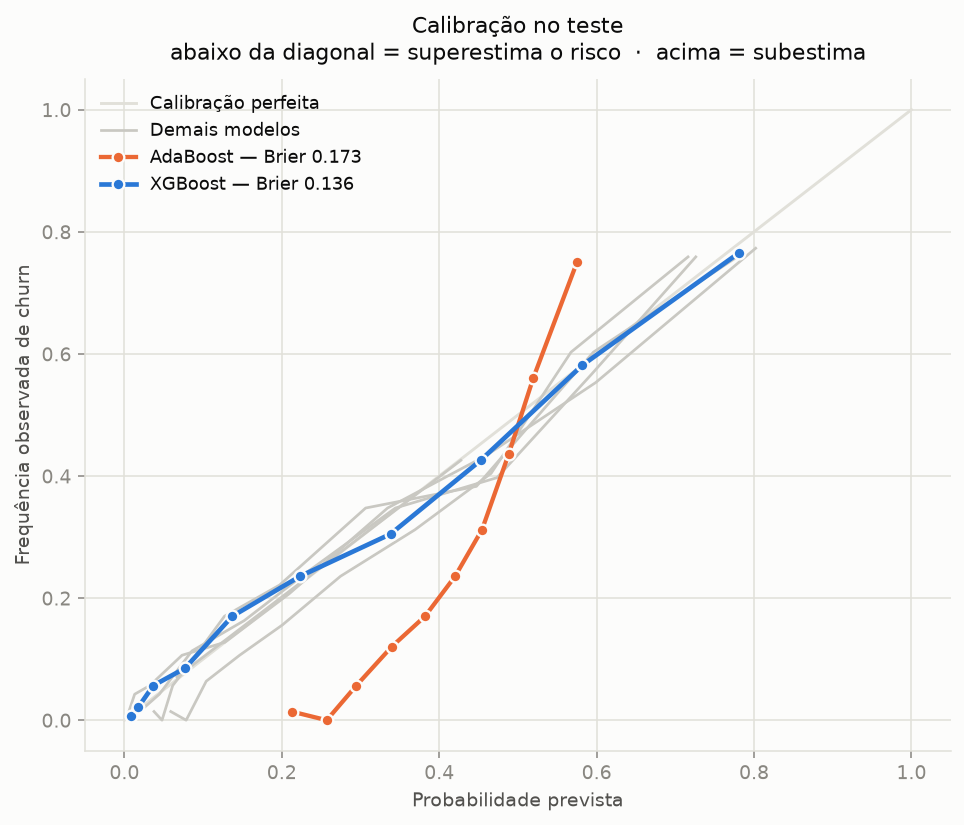

In [11]:
display(Image(filename=str(figuras / "curvas_calibracao.png")))

## 5. O que a operação enxerga

Nenhuma das métricas acima é o que a área de retenção usa. A campanha alcança um número limitado de clientes, então o que importa é **acertar no topo da lista**.

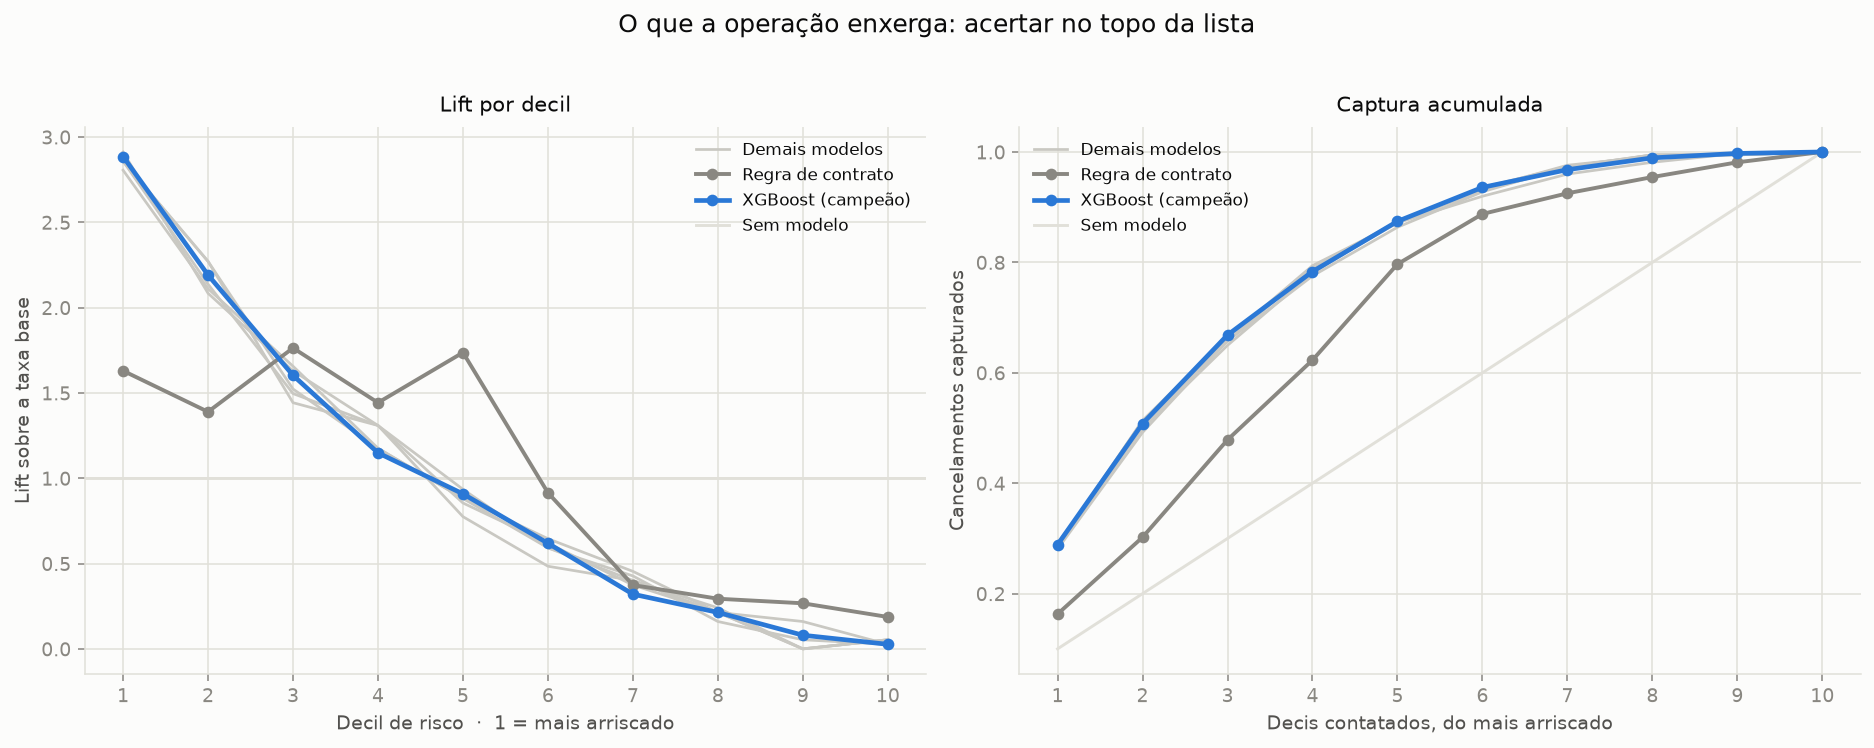

In [12]:
display(Image(filename=str(figuras / "comparacao_lift.png")))

In [13]:
lift = pd.DataFrame(comparacao["lift_por_decil"][comparacao["campeao_cv"]])
lift[["decil", "n", "churns", "taxa_churn", "lift", "captura_acumulada"]].round(3)

,decil,n,churns,taxa_churn,lift,captura_acumulada
0,1,141,108,0.766,2.886,0.289
1,2,141,82,0.582,2.191,0.508
2,3,141,60,0.426,1.603,0.668
3,4,141,43,0.305,1.149,0.783
4,5,141,34,0.241,0.908,0.874
5,6,140,23,0.164,0.619,0.936
6,7,141,12,0.085,0.321,0.968
7,8,141,8,0.057,0.214,0.989
8,9,141,3,0.021,0.080,0.997
9,10,141,1,0.007,0.027,1.000


O primeiro decil de risco tem **lift de 2,89**: entre os 10% mais arriscados, quase 3x mais gente cancela do que na carteira inteira. Contatando os **dois primeiros decis — 20% da base — a campanha alcança 51% de todos os cancelamentos**. A regra de contrato, no mesmo orçamento, alcança 30%.

Essa é a tradução da qual a Fase 4 parte: não "o AUC é 0,84", e sim "com orçamento para 282 clientes, o modelo põe metade dos cancelamentos futuros na sua lista".

## 6. Conclusões

**1. O modelo bate o baseline com folga, e os modelos aprendidos empatam entre si.**
Regra de contrato: ROC-AUC 0,729, PR-AUC 0,409. Modelos aprendidos: 0,841–0,851 e 0,657–0,672. A distância para o baseline é grande; a distância entre eles cabe no ruído do split.

**2. A comparação pareada é o que separa sinal de ruído.**
Comparando médias, tudo empata. Nos mesmos folds, os ensembles vencem a logística em 15/15 e 14/15 — pequeno, mas consistente. LightGBM e AdaBoost, ao contrário, **não** superam a logística.

**3. O campeão é XGBoost, por uma regra de desempate declarada.**
O stacking lidera por 0,0005 de PR-AUC e custa 37x mais para treinar. Entre modelos empatados, fica o mais barato.

**4. `TotalCharges` pode sair sem custo.**
Maior efeito observado: 0,0018 de ROC-AUC, menos de 0,15 desvio entre folds. O achado nº 4 da EDA está confirmado empiricamente.

**5. `class_weight="balanced"` custa caro e o AUC não avisa.**
Probabilidade média inflada de 0,268 para 0,416 contra taxa base real de 0,265, Brier de 0,138 para 0,169 — com ROC-AUC praticamente idêntico. O modelo de produção vai sem balanceamento.

**6. O AdaBoost é o contraexemplo útil do projeto.**
ROC-AUC competitivo e a pior calibração da escada, pior que a de uma regra de uma linha. Prova, dentro do próprio projeto, que escolher modelo por AUC quando o que se precisa é probabilidade leva à escolha errada.

### O que fica para a Fase 4

O modelo de produção (`models/modelo.joblib`) é um XGBoost calibrado de origem, com Brier 0,1356 no teste. A camada de decisão pode usar `predict_proba` diretamente como probabilidade de churn, sem estágio de recalibração — que é exatamente a condição que este notebook precisava estabelecer.